# 08 — Causal Self-Attention

## Goal

The previous bigram model predicts the next token using only the current
token.

To build a contextual language model, each token representation must be
able to incorporate information from other positions in the sequence.

Self-attention provides this mechanism.

Given hidden representations

$$
X \in \mathbb{R}^{B \times T \times C},
$$

self-attention constructs three learned representations:

$$
Q = XW_Q,
$$

$$
K = XW_K,
$$

and

$$
V = XW_V.
$$

The query and key representations determine **where to retrieve
information from**, while the value representations determine
**what information is retrieved**.

For autoregressive language modeling, attention must also be causal:
position $t$ may only use positions

$$
0,1,\ldots,t.
$$

This lesson implements causal self-attention explicitly from tensor
operations before introducing multi-head attention.

In [1]:
import torch

batch_size: int = 2
sequence_length: int = 4
embedding_dim: int = 6


x: torch.Tensor = torch.randn(
    batch_size, sequence_length, embedding_dim
)  # (B,T,C)
print(x.shape)

torch.Size([2, 4, 6])


## 1. Query, Key, and Value Projections

Using the same token representation for every role would force one vector
space to simultaneously represent:

- what a token is looking for,
- how a token should be matched,
- what information a token should contribute.

Self-attention instead learns separate projections:

$$
Q=XW_Q,
\qquad
K=XW_K,
\qquad
V=XW_V.
$$

These projections allow the model to learn different representations
for retrieval and content.

A useful interpretation is:

<pre>
Query  → what information does this position want?
Key    → how should this position be matched?
Value  → what information does this position provide?
</pre>

This interpretation is useful, but the vectors themselves are learned
continuous representations rather than manually assigned semantic
roles.

In [ ]:
attention_dim: int = 4

w_q: torch.Tensor = torch.randn(embedding_dim, attention_dim)
w_k: torch.Tensor = torch.randn(embedding_dim, attention_dim)
w_v: torch.Tensor = torch.randn(embedding_dim, attention_dim)

q: torch.Tensor = x @ w_q  # (B, T, d)
k: torch.Tensor = x @ w_k  # (B, T, d)
v: torch.Tensor = x @ w_v  # (B, T, d)

print("Q:", q.shape)
print("K:", k.shape)
print("V:", v.shape)

Q: torch.Size([2, 4, 4])
K: torch.Size([2, 4, 4])
V: torch.Size([2, 4, 4])


In [4]:
scores: torch.Tensor = q @ k.transpose(-2, -1)
print("scores:", scores.shape)

scores: torch.Size([2, 4, 4])


## 2. Pairwise Attention Scores

The matrix

$$
QK^T
$$

computes every query-key dot product.

For batched input,

$$
Q \in \mathbb{R}^{B\times T\times d}
$$

and

$$
K^T \in \mathbb{R}^{B\times d\times T},
$$

so

$$
QK^T
\in
\mathbb{R}^{B\times T\times T}.
$$

For one batch element,

$$
S_{ij}
=
q_i \cdot k_j.
$$

The dimensions mean:

<pre>
dim 0 → batch
dim 1 → query position
dim 2 → key position
</pre>

Therefore,

`scores[b, i, j]`

measures how strongly query position `i` matches key position `j` in
batch example `b`.

In [5]:
import math

print(scores)

scores = scores / math.sqrt(attention_dim)  # squard root

print(scores)

tensor([[[  1.4471,   5.4103,  -0.3114,  -1.6697],
         [  5.2720,   7.8484,   2.7688, -10.6754],
         [  3.0139,   4.2903,   1.7622,  -8.0434],
         [  1.6920,   2.3654,   1.8186,  -0.4517]],

        [[ -6.2189,   6.8229,  22.2204,  -1.1498],
         [  2.5351,  -4.0820,   8.6114,  -4.8183],
         [ -0.7701,   4.5954, -21.6696,   8.7156],
         [  5.1134,  -7.5280,  -8.6464,  -2.7724]]])
tensor([[[  0.7236,   2.7052,  -0.1557,  -0.8349],
         [  2.6360,   3.9242,   1.3844,  -5.3377],
         [  1.5070,   2.1451,   0.8811,  -4.0217],
         [  0.8460,   1.1827,   0.9093,  -0.2258]],

        [[ -3.1095,   3.4114,  11.1102,  -0.5749],
         [  1.2676,  -2.0410,   4.3057,  -2.4091],
         [ -0.3851,   2.2977, -10.8348,   4.3578],
         [  2.5567,  -3.7640,  -4.3232,  -1.3862]]])


The dot products are scaled by

$$
\frac{1}{\sqrt d}
$$

to keep their magnitude controlled as the query/key dimension grows.

The numerical motivation was studied earlier when deriving scaled
dot-product attention.

## 3. Causal Masking

During autoregressive language modeling, a token must not access future
tokens.

For query position $i$, only key positions satisfying

$$
j \leq i
$$

are allowed.

query 0 → key 0 only

query 1 → keys 0,1

query 2 → keys 0,1,2

query 3 → keys 0,1,2,3

The causal mask is therefore lower triangular.

Disallowed attention scores are replaced with

$$
-\infty.
$$

After softmax,

$$
e^{-\infty}=0,
$$

so future positions receive zero attention probability.

In [6]:
causal_mask: torch.Tensor = torch.tril(
    torch.ones(sequence_length, sequence_length, dtype=torch.bool)
)  # torch.tril -> trianglar low


print(causal_mask)

tensor([[ True, False, False, False],
        [ True,  True, False, False],
        [ True,  True,  True, False],
        [ True,  True,  True,  True]])


In [ ]:
# apply masks

masked_scores: torch.Tensor = scores.masked_fill(~causal_mask, float("-inf"))
# e^(-inf) = 0 => softmax score
print(masked_scores)

tensor([[[  0.7236,     -inf,     -inf,     -inf],
         [  2.6360,   3.9242,     -inf,     -inf],
         [  1.5070,   2.1451,   0.8811,     -inf],
         [  0.8460,   1.1827,   0.9093,  -0.2258]],

        [[ -3.1095,     -inf,     -inf,     -inf],
         [  1.2676,  -2.0410,     -inf,     -inf],
         [ -0.3851,   2.2977, -10.8348,     -inf],
         [  2.5567,  -3.7640,  -4.3232,  -1.3862]]])


In [8]:
attention_weights: torch.Tensor = torch.softmax(
    masked_scores,
    dim=-1,
)

print(attention_weights.shape)

print(attention_weights.sum(dim=-1))

torch.Size([2, 4, 4])
tensor([[1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000]])


In [9]:
output: torch.Tensor = attention_weights @ v

print(output.shape)

torch.Size([2, 4, 4])


## 4. Testing Causality

A causal attention mask should guarantee that the representation at
position $t$ depends only on positions

$$
0, 1, \ldots, t.
$$

Therefore, changing a future token must not change the outputs of earlier
positions.

Suppose two sequences are identical up to position $k$ but differ after
that position.

For every position

$$
t \leq k,
$$

causal self-attention should produce the same output for both sequences.

This provides a stronger correctness test than only inspecting the mask
itself.

In [10]:
import math


def causal_attention(
    x: torch.Tensor,
    w_q: torch.Tensor,
    w_k: torch.Tensor,
    w_v: torch.Tensor,
) -> torch.Tensor:
    q: torch.Tensor = x @ w_q
    k: torch.Tensor = x @ w_k
    v: torch.Tensor = x @ w_v

    head_dim: int = q.shape[-1]

    scores: torch.Tensor = (q @ k.transpose(-2, -1)) / math.sqrt(head_dim)

    sequence_length: int = x.shape[1]

    positions: torch.Tensor = torch.arange(
        sequence_length,
        device=x.device,
    )

    causal_mask: torch.Tensor = positions.unsqueeze(0) <= positions.unsqueeze(1)

    scores = scores.masked_fill(
        ~causal_mask,
        float("-inf"),
    )

    weights: torch.Tensor = torch.softmax(
        scores,
        dim=-1,
    )

    return weights @ v

In [11]:
torch.manual_seed(42)

batch_size: int = 1
sequence_length: int = 5
embedding_dim: int = 6
attention_dim: int = 4

x_original: torch.Tensor = torch.randn(
    batch_size,
    sequence_length,
    embedding_dim,
)

x_modified: torch.Tensor = x_original.clone()

x_modified[:, 3:, :] = torch.randn_like(x_modified[:, 3:, :]) * 100.0


w_q: torch.Tensor = torch.randn(
    embedding_dim,
    attention_dim,
)

w_k: torch.Tensor = torch.randn(
    embedding_dim,
    attention_dim,
)

w_v: torch.Tensor = torch.randn(
    embedding_dim,
    attention_dim,
)


output_original: torch.Tensor = causal_attention(
    x_original,
    w_q,
    w_k,
    w_v,
)

output_modified: torch.Tensor = causal_attention(
    x_modified,
    w_q,
    w_k,
    w_v,
)

print(
    torch.allclose(
        output_original[:, :3, :],
        output_modified[:, :3, :],
    )
)

True


In [12]:
def full_attention(
    x: torch.Tensor,
    w_q: torch.Tensor,
    w_k: torch.Tensor,
    w_v: torch.Tensor,
) -> torch.Tensor:
    q: torch.Tensor = x @ w_q
    k: torch.Tensor = x @ w_k
    v: torch.Tensor = x @ w_v

    head_dim: int = q.shape[-1]

    scores: torch.Tensor = (q @ k.transpose(-2, -1)) / math.sqrt(head_dim)

    weights: torch.Tensor = torch.softmax(
        scores,
        dim=-1,
    )

    return weights @ v


full_original = full_attention(
    x_original,
    w_q,
    w_k,
    w_v,
)

full_modified = full_attention(
    x_modified,
    w_q,
    w_k,
    w_v,
)

print(
    torch.allclose(
        full_original[:, :3, :],
        full_modified[:, :3, :],
    )
)

False


## 5. A Causal Self-Attention Module

The causal attention computation can now be organized into a reusable
module.

Previously studied components such as linear transformations and
softmax are delegated to PyTorch.

The attention-specific computation remains explicit:

<pre>
X
├── Q projection
├── K projection
└── V projection
        ↓
scaled QKᵀ
        ↓
causal masking
        ↓
softmax
        ↓
weighted sum of V
        ↓
output projection
</pre>

The output projection maps the attention representation back to the
model embedding dimension so that it can later participate in residual
connections.

In [ ]:
from torch import nn


class CausalSelfAttention(nn.Module):
    def __init__(self, embedding_dim: int, attention_dim: int) -> None:
        super().__init__()

        self.query = nn.Linear(embedding_dim, attention_dim, bias=False)
        self.key = nn.Linear(embedding_dim, attention_dim, bias=False)
        self.value = nn.Linear(embedding_dim, attention_dim, bias=False)

        self.output = nn.Linear(attention_dim, embedding_dim, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        q: torch.Tensor = self.query(x)
        k: torch.Tensor = self.key(x)
        v: torch.Tensor = self.value(x)

        head_dim: int = q.shape[-1]

        scores: torch.Tensor = (q @ k.transpose(-2, -1)) / math.sqrt(head_dim)

        sequence_length: int = x.shape[1]

        positions: torch.Tensor = torch.arange(sequence_length, device=x.device)

        key_positions = positions.unsqueeze(0)  # (1, T)
        query_positions = positions.unsqueeze(1)  # (T, 1)

        causal_mask = key_positions <= query_positions

        scores = scores.masked_fill(~causal_mask, float("-inf"))

        weights: torch.Tensor = torch.softmax(scores, dim=-1)

        attended: torch.Tensor = weights @ v

        return self.output(attended)

In [17]:
attention = CausalSelfAttention(
    embedding_dim=6,
    attention_dim=4,
)

x: torch.Tensor = torch.randn(
    2,
    5,
    6,
)

output: torch.Tensor = attention(x)

print("input:", x.shape)
print("output:", output.shape)

input: torch.Size([2, 5, 6])
output: torch.Size([2, 5, 6])


## 6. Visualizing Attention Weights

For one attention head, the attention weights have shape

$$
(B,T,T).
$$

For a particular batch example, the matrix

$$
A \in \mathbb{R}^{T\times T}
$$

contains one attention distribution for every query position.

Each row corresponds to a query position.

Each column corresponds to a key position.

Therefore,

$$
A_{ij}
$$

describes how much information query position $i$ retrieves from
position $j$.

In causal self-attention, entries above the diagonal must be zero.

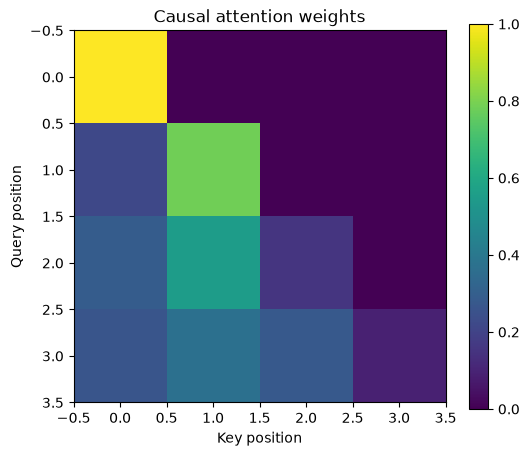

In [18]:
import matplotlib.pyplot as plt

weights: torch.Tensor = attention_weights[0].detach().cpu()
plt.figure(figsize=(6, 5))

plt.imshow(weights)

plt.xlabel("Key position")
plt.ylabel("Query position")
plt.title("Causal attention weights")

plt.colorbar()

plt.show()

## 7. Combining Causal and Padding Masks

Causal masking and padding masking solve different problems.

The causal mask enforces the autoregressive constraint:

$$
j \leq i.
$$

A padding mask indicates whether a key position corresponds to a real
token or only to padding.

For example:

<pre>
tokens:
A B C D
E F PAD PAD
</pre>

the key-validity mask is

<pre>
True True True True
True True False False
</pre>

A position may be attended to only when it satisfies both conditions:

1. it is not in the **future**,
2. it is a **real** token.

Therefore,

$$
\text{allowed}
=
\text{causal}
\land
\text{valid key}.
$$

In [19]:
padding_mask: torch.Tensor = torch.tensor(
    [
        [True, True, True, True],
        [True, True, False, False],
    ],
    dtype=torch.bool,
)

key_mask: torch.Tensor = padding_mask.unsqueeze(1)

print(key_mask.shape)

torch.Size([2, 1, 4])


In [20]:
combined_mask: torch.Tensor = causal_mask.unsqueeze(0) & key_mask

In [23]:
masked_scores: torch.Tensor = scores.masked_fill(
    ~combined_mask,
    float("-inf"),
)

attention_weights: torch.Tensor = torch.softmax(
    masked_scores,
    dim=-1,
)

print(attention_weights[1, :, 2:])

assert torch.allclose(
    attention_weights[1, :, 2:],
    torch.zeros_like(attention_weights[1, :, 2:]),
)

tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.]])


## 8. Comparing with PyTorch Scaled Dot-Product Attention

We have now explicitly implemented the complete scaled dot-product
attention computation.

PyTorch also provides an optimized implementation:

`torch.nn.functional.scaled_dot_product_attention`

At this point, the function is useful as a reference implementation
rather than as a replacement for understanding the algorithm.

For equivalent inputs and masking rules, both implementations should
produce numerically close outputs.

In [ ]:
from torch.nn import functional as F

manual_scores: torch.Tensor = (q @ k.transpose(-2, -1)) / math.sqrt(q.shape[-1])

manual_mask: torch.Tensor = key_positions <= query_positions

manual_scores = manual_scores.masked_fill(
    ~manual_mask,
    float("-inf"),
)

manual_weights: torch.Tensor = torch.softmax(
    manual_scores,
    dim=-1,
)

manual_output: torch.Tensor = manual_weights @ v


torch_output: torch.Tensor = F.scaled_dot_product_attention(
    q,
    k,
    v,
    is_causal=True,
    dropout_p=0.0,
)

## Takeaways

- Self-attention allows token representations to retrieve information
  from other token positions.

- Query and key vectors determine matching scores, while value vectors
  provide the information being aggregated.

- Batched query-key multiplication produces

  $$
  (B,T,d)@(B,d,T)
  \rightarrow
  (B,T,T).
  $$

- The attention matrix contains one probability distribution over key
  positions for every query position.

- Causal masking prevents information from flowing from future tokens to
  earlier positions.

- Padding masking prevents artificial padding positions from being used
  as content.

- Causal and padding masks solve different problems and can be combined
  through broadcasting.

- Attention outputs are weighted sums of value vectors.

- The output projection maps the attention representation back into the
  model hidden dimension.

- Behavioral causality tests provide stronger evidence than merely
  inspecting a triangular mask.

- Once the mechanism is understood explicitly, optimized attention
  implementations can be used as references or performance backends.